#### Teoría de los Circuitos 2
# Trabajo semanal 3
#### Leandro Robledo

Diseñar un filtro pasabajos Bessel  para aproximar un Retardo de Grupo  
 constante en banda de paso que cumpla con la siguiente plantilla:
![plantilla](plantilla.PNG)

1.Utilizando el método de Storch ( pag. 403 del Schaumann ) obtener la [T(s) Bessel de orden N = 2, 3 y 4](#dis_bessel) 

2.Elegir la T(s) con el mínimo orden que cumple con[ $\alpha_{min}=1db$](#ordenB)

3.Evaluar el [Retardo de Grupo $D(2.5)$ Expresar en forma porcentual % el error o desviamiento respecto a $D(0)$](#retDeGrupo)

4.[Sintetizar el circuito normalizado](#simu) con estructuras Sallen-Key con K=1 ( realimentación negativa unitaria )                                    
![sallenkey](sallenkey.PNG)

Bonus:

+10 💎 Simulación numérica en python utilizando la función[ pretty_print_lti( num, den ) para el 1)](#prettyPrint)

+10 💎 Desnormalizar los componentes para obtener un [$D(0)=200us$](#desnorm)

+10 💎 Simulación Circuital con los valores desnormalizados. Medir el $D(\omega)$resultante (*) indicar con un marker el $\Delta D(\omega)$ en banda de paso.


### 1. Calculo de filtros Bessel <a id="dis_bessel"></a>
![Diseño Bessel](Bessel.jpeg) 

### 2. Determinacion con Alpha Maximo<a id="ordenB"></a>
![Alpha max](ordenB.jpeg) 

### 3. Calculo de Retardo de grupo <a id="retDeGrupo"></a>
![Retardo de grupo en 2.5 y 0](retGrupo.jpeg) 

In [51]:
# Importo librerias de python para trabajar

import numpy as np
from scipy import signal as sig
import sympy as sp
from matplotlib import pyplot as plt
from pytc2.remociones import remover_polo_dc
from pytc2.general import a_equal_b_latex_s, print_latex, s, symbfunc2tf, factorSOS
from pytc2.sistemas_lineales import bodePlot, pzmap, GroupDelay, analyze_sys
from pytc2.sistemas_lineales import pretty_print_lti
#verifico por computadora. 
d=1.8389/(1.8389**2+(2.5-1.75438)**2) + 1.8389/(1.8389**2+(2.5+1.75438)**2) + 2.32218/(2.32218**2+2.5**2)
d_sympy = sp.Float(d, 5)

print_latex(a_equal_b_latex_s('D(2.5)', d_sympy))

<IPython.core.display.Math object>

In [63]:
# Importo librerias de python para trabajar

import numpy as np
from scipy import signal as sig
import sympy as sp
from matplotlib import pyplot as plt
from pytc2.remociones import remover_polo_dc
from pytc2.general import a_equal_b_latex_s, print_latex, s, symbfunc2tf, factorSOS
from pytc2.sistemas_lineales import bodePlot, pzmap, GroupDelay, analyze_sys
from pytc2.sistemas_lineales import pretty_print_lti
#verifico por computadora. 
d=(58.56e-6/(58.56e-6**2+(55.85e-6)**2))*2 + 73.99194e-6/(73.99194e-6**2)
d_sympy = sp.Float(d, 7)
d_seg_pi=(2*sp.pi)/(d_sympy )
d_seg = sp.N((2*sp.pi)/d_sympy, 15)
print_latex(a_equal_b_latex_s('D(0)', d_sympy))
print_latex(a_equal_b_latex_s('(D(0)/2 pi)^ -1', d_seg_pi))
print_latex(a_equal_b_latex_s('(D(0)/2 pi)^-1', d_seg))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### 4. Sintetizacion con Sallen Key <a id="simu"></a>

Polos= [-1.83890732+1.75438096j -1.83890732-1.75438096j -2.32218535+0.j        ]


<IPython.core.display.Math object>

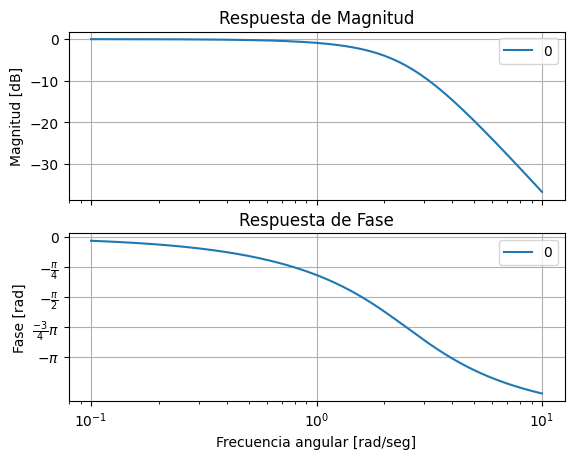

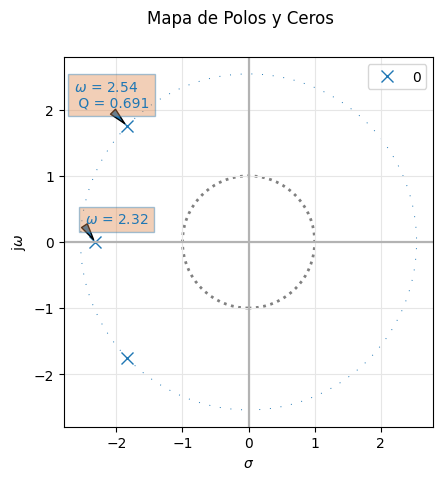

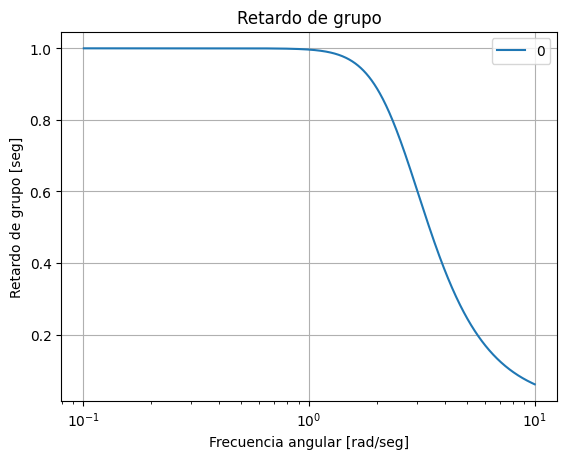

In [32]:
# Librerías externas NumPy, SciPy y Matplotlib
from scipy.signal import TransferFunction
import matplotlib.pyplot as plt
from pytc2.sistemas_lineales import pzmap, GroupDelay, bodePlot
import numpy as np
import scipy.signal as sig
from pytc2.sistemas_lineales import analyze_sys, pretty_print_bicuad_omegayq, tf2sos_analog, pretty_print_SOS
from pytc2.general import print_subtitle

num = np.array([15])
den = np.array([1, 6, 15, 15])
p=np.roots(den)
z=[]
k=15
print ("Polos=", p)
num, den = sig.zpk2tf(z,p,k)
mi_tf = sig.TransferFunction(num,den)
analyze_sys( mi_tf )

this_sos = tf2sos_analog(num, den)
pretty_print_SOS(this_sos, mode='omegayq')


In [45]:
from scipy.optimize import least_squares
import numpy as np

w0_target = 2.542
lineal_target = 3.67892 #(w0/Q)

def error(x):

    R1, R2, C1, C2 = x

    # ecuaciones del filtro
    w0 = 1 / np.sqrt(R1 * R2 * C1 * C2)

    lineal = (
        (R1 + R2) /
        (R1 * R2 * C1)
    )

    # errores principales
    eq1 = (w0 - w0_target)
    eq2 = (lineal - lineal_target)

    # penalizaciones
    pen_R = 0.01 * np.log10(R1 / R2)
    pen_C = 0.01 * np.log10(C1 / C2)

    # penaliza capacitores gigantes
    pen_bigC = 0.01 * (C1 + C2)

    return [
        eq1,
        eq2,
        pen_R,
        pen_C,
        pen_bigC
    ]

x0 = [10e3, 10e3, 100e-9, 100e-9]

bounds_lower = [1e3, 1e3, 1e-9, 1e-9]
bounds_upper = [1e6, 1e6, 1e-4, 1e-4]

sol = least_squares(
    error,
    x0,
    bounds=(bounds_lower, bounds_upper)
)

print(sol.x)

[7.63164035e+04 7.63164035e+04 7.12345970e-06 3.73014254e-06]


![calculo Sallen Key](SallenKeyDesarrollo.jpeg) 
![Simulacion](simulacion.PNG) 

### Bonus: Simulacion Con prettyprint de bessel de los primeros 3 ordenes <a id="prettyPrint"></a>


Bessel N=2:
Polos= [-1.5+0.8660254j -1.5-0.8660254j]


<IPython.core.display.Math object>

Bessel N=3:
Polos= [-1.83890732+1.75438096j -1.83890732-1.75438096j -2.32218535+0.j        ]


<IPython.core.display.Math object>

Bessel N=4:
Polos= [-2.1037894+2.65741804j -2.1037894-2.65741804j -2.8962106+0.86723413j
 -2.8962106-0.86723413j]


<IPython.core.display.Math object>

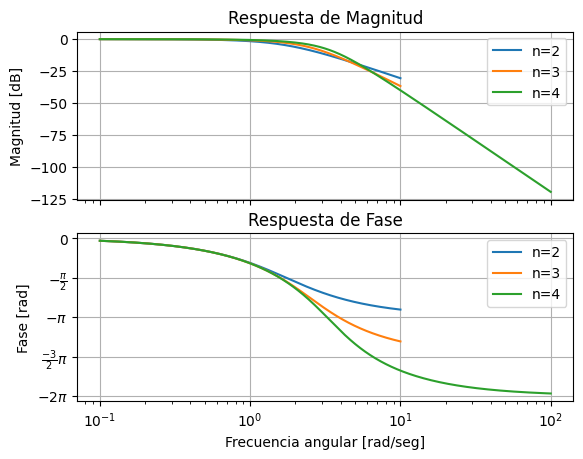

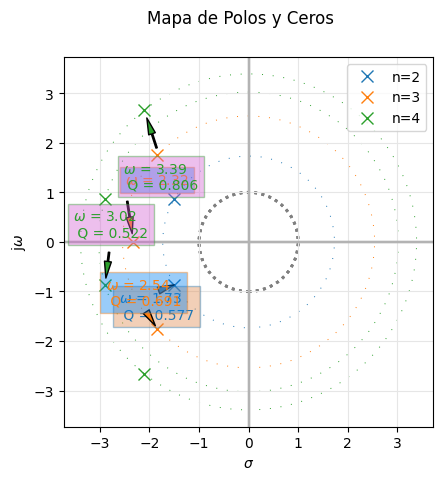

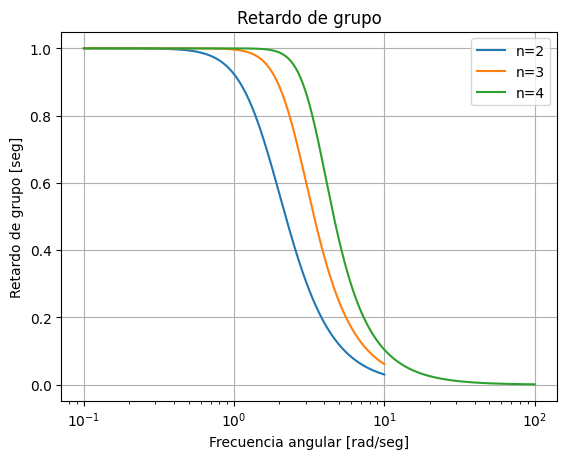

In [50]:
from scipy.signal import TransferFunction
import matplotlib.pyplot as plt
from pytc2.sistemas_lineales import pzmap, GroupDelay, bodePlot
import numpy as np
import scipy.signal as sig
from pytc2.sistemas_lineales import analyze_sys, pretty_print_bicuad_omegayq, tf2sos_analog, pretty_print_SOS
from pytc2.general import print_subtitle

#BESSEL 2
num = np.array([3])
den = np.array([1, 3, 3])
p=np.roots(den)
z=[]
k=3
print ("Bessel N=2:")
print ("Polos=", p)
num, den = sig.zpk2tf(z,p,k)
mi_tf = sig.TransferFunction(num,den)
analyze_sys( mi_tf, sys_name=['n=2'] )

this_sos = tf2sos_analog(num, den)
pretty_print_SOS(this_sos, mode='omegayq')

#BESSEL 3
num = np.array([15])
den = np.array([1, 6, 15, 15])
p=np.roots(den)
z=[]
k=15
print ("Bessel N=3:")
print ("Polos=", p)
num, den = sig.zpk2tf(z,p,k)
mi_tf = sig.TransferFunction(num,den)
analyze_sys( mi_tf, sys_name=['n=3'])

this_sos = tf2sos_analog(num, den)
pretty_print_SOS(this_sos, mode='omegayq')

#BESSEL 4
num = np.array([105])
den = np.array([1, 10, 45, 105, 105])
p=np.roots(den)
z=[]
k=105
print ("Bessel N=4:")
print ("Polos=", p)
num, den = sig.zpk2tf(z,p,k)
mi_tf = sig.TransferFunction(num,den)
analyze_sys( mi_tf, sys_name=['n=4'] )

this_sos = tf2sos_analog(num, den)
pretty_print_SOS(this_sos, mode='omegayq')

### Bonus: Desnormalizacion de 200us <a id="desnorm"></a>

![desnomr 200us](desnormalizacion.jpeg) 
![retado de grupo desnormalizado comparacion ](deltaW.PNG) 
